In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pylab as pl
from os.path import exists
from scipy.io import loadmat


In [2]:
corrinds=[29.96,30.34,30.69,31.03,31.36,31.69,32.05,32.39,32.77,33.15,33.44]

In [9]:

coast='smooth'
WR=[]
RRR=[]

for lat in corrinds:
    WRin=[]
    RRRin=[]
    for l in np.arange(0,4,1):
        name='../datafiles/ctwmodel/dispr' + str(lat) + 'mode' +str(l) + '.mat'
        if exists(name) == True:
            dispfile=loadmat(name)
            wr, rrr = dispfile['dispcurve'][:,0],dispfile['dispcurve'][:,1]
            WRin.append(wr)
            RRRin.append(rrr)
    WR.append(WRin)
    RRR.append(RRRin)

freqMITgcm=0.84

## Plotting modes vs MITgcm output

In [4]:
def openbrink(loc,coast):
	u=[]
	v=[]
	w=[]
	r=[]
	p=[]
	k=[]
	omega=[]
	epe=[]
	eke=[]


	for l in np.arange(0,5,1):
		if exists( '../datafiles/ctwmodel/dataSVB'+ str(loc) +'mode' + str(l) + '.mat') == True:
			uo,vo,wo,ro,po,z,ko,omegao, xpl, xxx, zzz, zgr, xgr, epeo, ekeo = get_Brink( '../datafiles/ctwmodel/dataSVB'+ str(loc) +'mode' + str(l) + '.mat')	
		else: 
			uo=0
			vo=0
			wo=0
			ro=0
			po=0
			ko=0
			omegao=0
			epeo=0
			ekeo=0
			
		u.append(uo) 
		v.append(vo)
		w.append(wo)
		r.append(ro)
		p.append(po)
		k=np.append(k,ko)
		omega=np.append(omega,omegao)
		epe=np.append(epe,epeo)
		eke=np.append(eke,ekeo)
	
	return u,v,w,r,p,k,omega,epe,eke,xgr,zgr
    
def get_Brink(file_fig):#,file_h): #, file_ratio):
    # Brink mode
    file = loadmat(file_fig)
    z, xpl, xxx, zzz, xgr, zgr = file['z'][0,:], file['xpl'][0,:], file['xxx'][0,:], file['zzz'][0,:], file['xgr'], file['zgr']
    k, omega,epe,eke = file['wavenumber'][0][0], file['frequency'][0][0], file['epe'][0][0],file['eke'][0][0]

    # (u is cross-shore and v is alongshore in Brink.)
    p0, u0, v0, w0, r0 = file['p'], file['u'],file['v'], file['wvel'], file['rho']

    scale=0.2
    w = w0.transpose() * 0.01 * scale # cms-1 to ms-1 and normalization (?)
    u = u0.transpose() * 0.01 * scale # cms-1 to ms-1 and normalization 
    v = v0.transpose() * 0.01 * scale # cms-1 to ms-1 and normalization 
    r = r0.transpose() * 1.0 * scale # mg/cm³ to kg/m³ and normalization
    p = p0.transpose() * 0.1 * scale # dyn/cm² to 0.1 Pa (or kg m-1 s-2) and normalization
    

    
    return(u,v,w,r,p,z,k,omega,xpl, xxx, zzz,zgr.transpose(),xgr.transpose(), epe, eke)


In [5]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 6),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 1000
plt.rcParams['savefig.dpi'] = 1000

In [6]:
width=[16.10, 14.98,14.63,14.40,14.36,9.87,9.51,4.81,4.78,1.31,1.17]


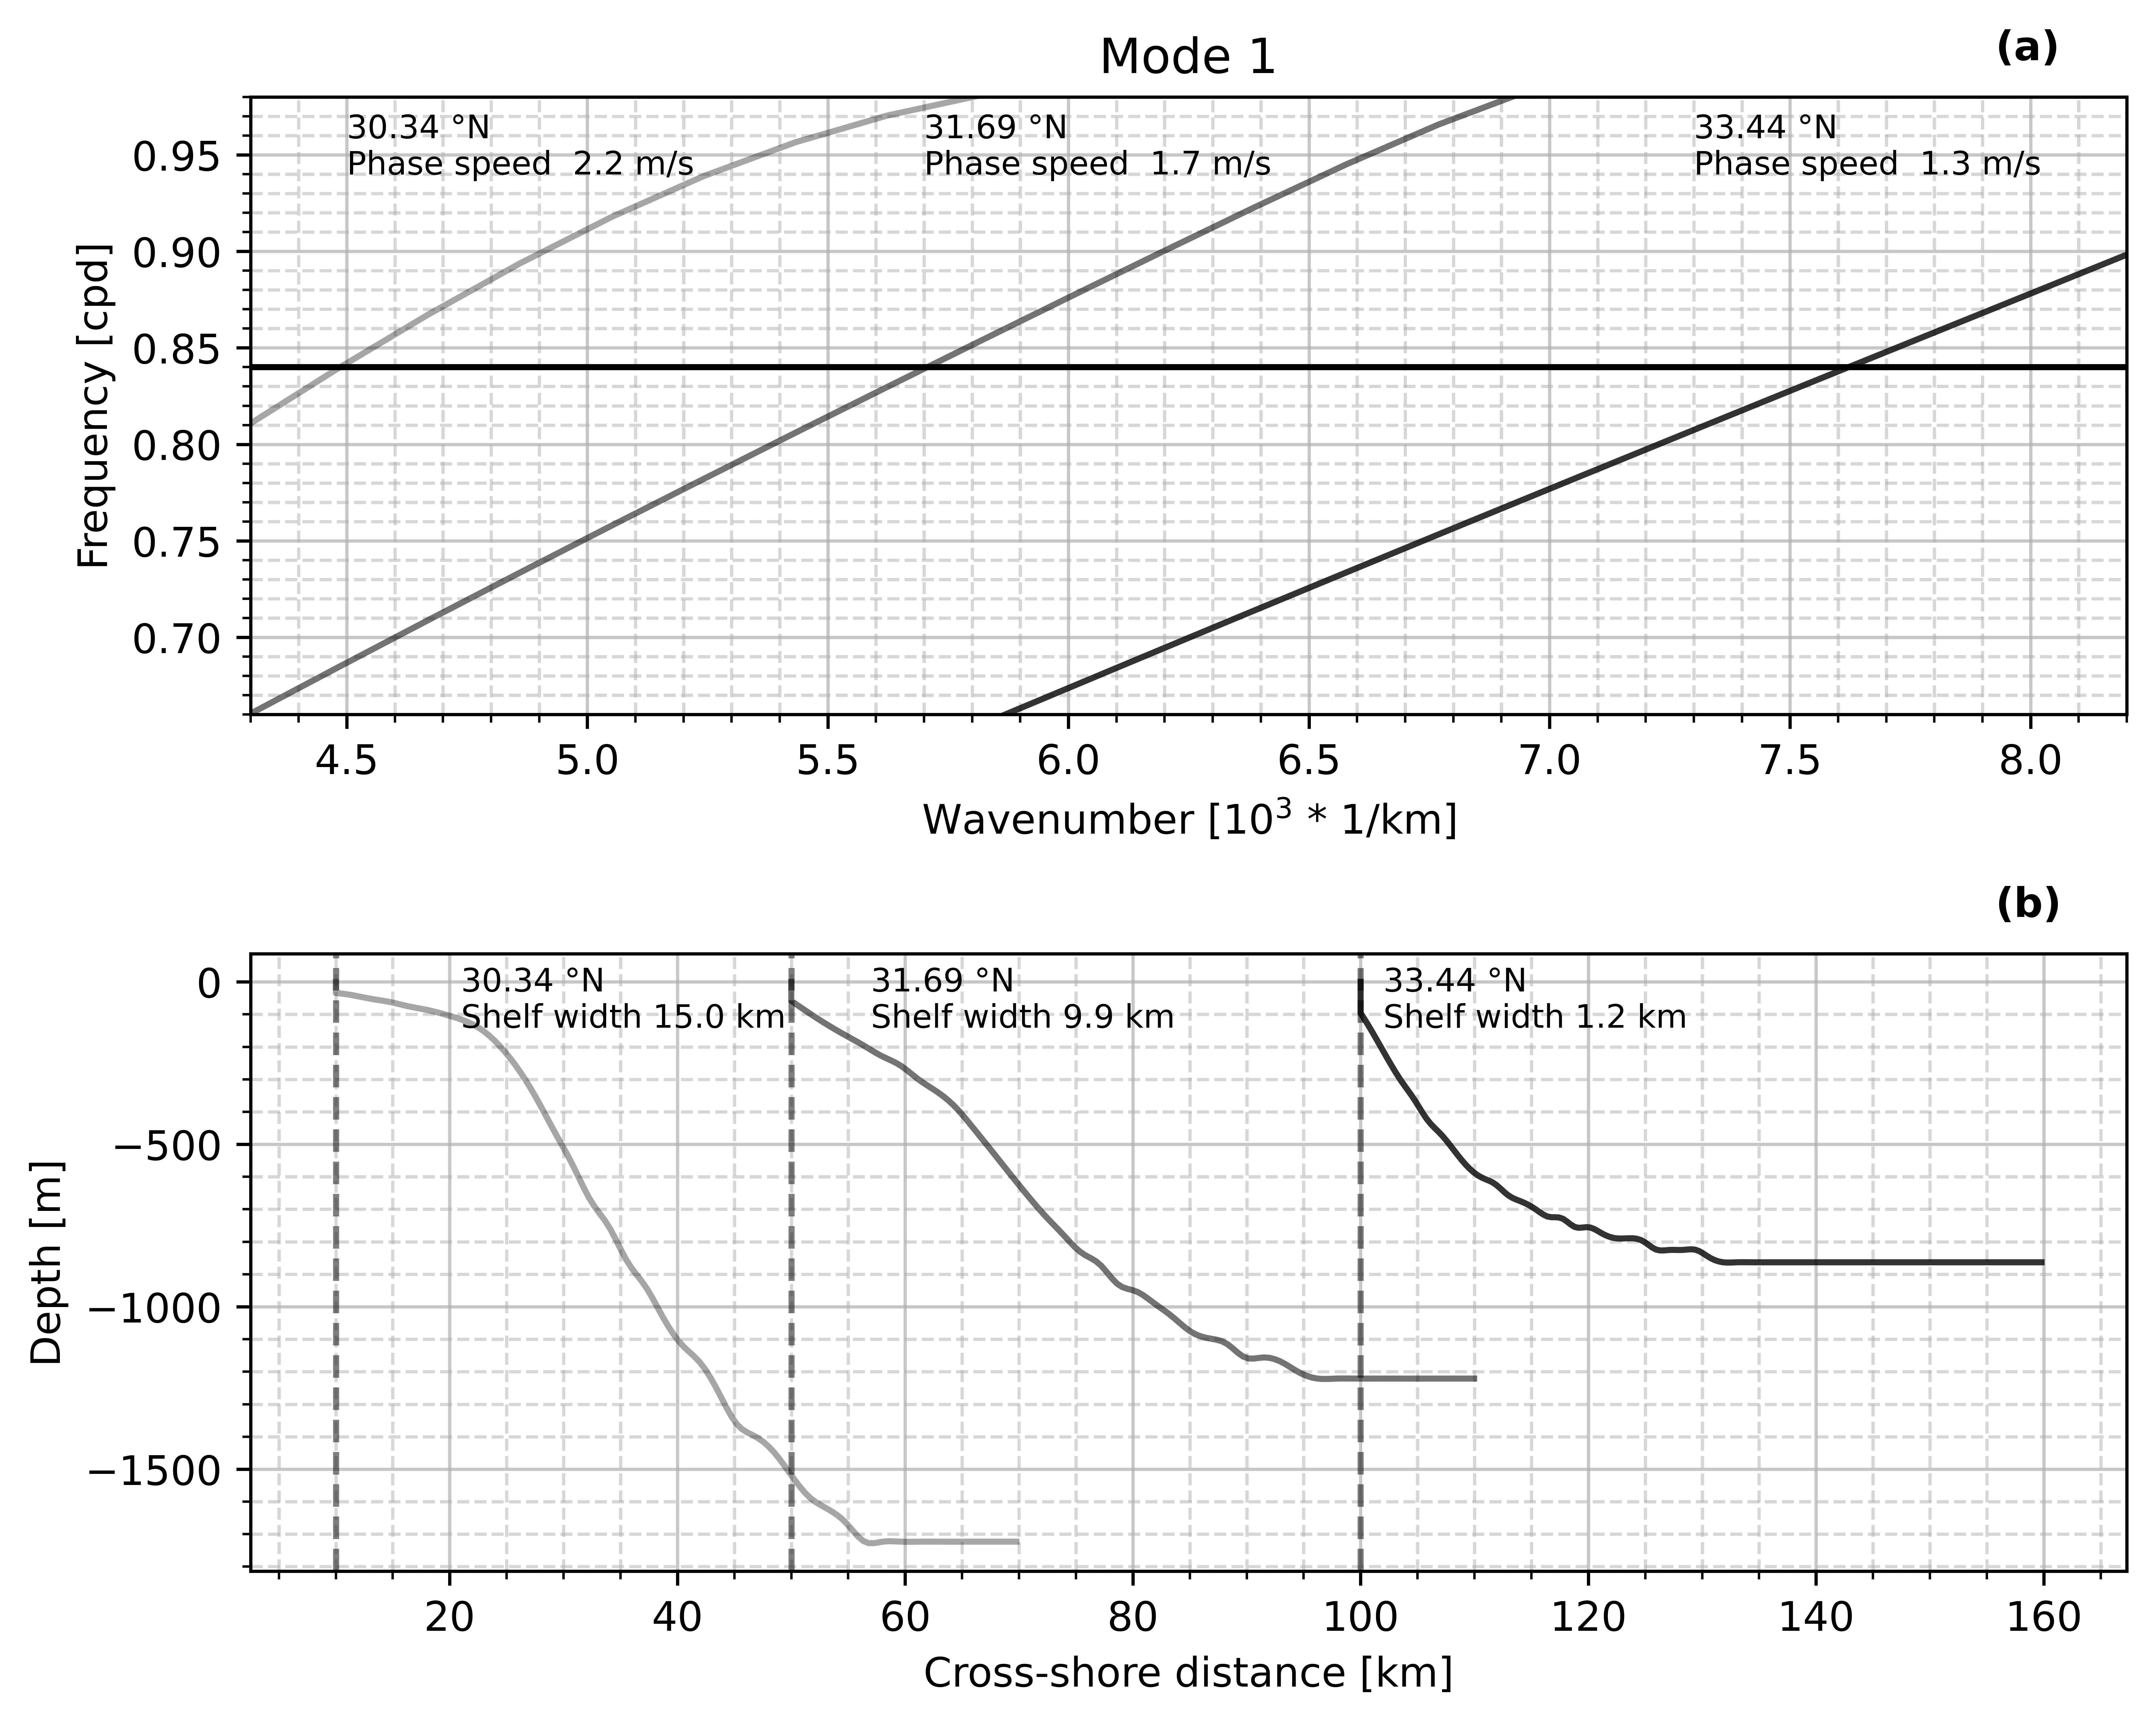

In [26]:
xlab='Wavenumber [10$^3$ * 1/km]'
ylab='Frequency [cpd]'
omega=(2*np.pi)/(23*60*60 + 56*60 + 4.1)

k=0
fig,axin=plt.subplots(2)
ax=axin[0]
ax.axhline(freqMITgcm,label=f'Maximum frequency\nMITgcm',color='k')
indstext=[4.5,5.7,7.3]
p=0
for i in [1,5,10]:
    if len(RRR[i])>k:
        fp=np.where((RRR[i][k]/(2*np.pi))*3600*24<freqMITgcm)[0][-1]
        c=(RRR[i][k][fp]/(2*np.pi))/(WR[i][k][fp]*100/(2*np.pi))
        ax.plot((WR[i][k]/(2*np.pi))*100000000,(RRR[i][k]/(2*np.pi))*3600*24,color='k',alpha=0.3+i*0.05)
        ax.text(indstext[p] ,0.94 , f'{corrinds[i]} °N\nPhase speed  {c:.1f} m/s', fontsize=8)
        p=p+1
ax.set(xlabel=xlab, ylabel=ylab)
ax.set_title(f'Mode {k+1}')
#ax.legend(fontsize=10,bbox_to_anchor=(1.15, 1))
if k==0:
    ax.fill_between(np.arange(0.002,0.013,0.0005),np.ones(len(np.arange(0.002,0.013,0.0005)))*(2*omega*np.sin(np.deg2rad(corrinds[0]))*24*3600)/(2*np.pi),np.ones(len(np.arange(0.002,0.013,0.0005)))*(2*omega*np.sin(np.deg2rad(corrinds[-1]))*24*3600)/(2*np.pi),color='gray',alpha=0.2)
    ax.set_xlim((4.3,8.2))
    ax.set_ylim((0.66,0.98))

ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax.text(0.93, 1.06, '(a)', fontweight='bold', color='k', 
transform=ax.transAxes)
ax=axin[1]

xlab='Cross-shore distance [km]'
ylab='Depth [m]'
for i in [1,5,10]:
    lat=corrinds[i]
    u,v,w,r,p,k,omega,epe,eke,xgr,zgr = openbrink(lat,coast)
    ax.axvline(10*i,linestyle='dashed',color='k', alpha=0.5)
    if zgr[0][xgr[0]<60][0]!=0:
        zgrin=np.append(0,zgr[0][xgr[0]<60])
        xgrin=np.append(0,xgr[0][xgr[0]<60])
    else:
        zgrin=zgr[0][xgr[0]<60]
        xgrin=xgr[0][xgr[0]<60]
    ax.plot(xgrin+10*i,zgrin,color='k',alpha=0.3+i*0.05)
    ax.text(xgrin[0]+10*i+12-i , zgrin[0]-140, f'{corrinds[i]} °N\nShelf width {width[i]:.1f} km', fontsize=8)
ax.set(xlabel=xlab, ylabel=ylab)
#ax.set_ylim((-1000,0))
ax.minorticks_on()
ax.text(0.93, 1.06, '(b)', fontweight='bold', color='k', 
transform=ax.transAxes)

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
fig.tight_layout()
plt.savefig('../figures/DISP_fig9.pdf', bbox_inches='tight')